In [9]:
from langgraph.checkpoint.postgres import PostgresSaver
from langgraph.constants import START, END
from langgraph.graph import StateGraph
from langchain_postgres import PGVector
from app import dependencies
from app.agents.node import (
    handle_intent_classification,
    handle_knowledge_base,
    handle_appointment,
    handle_casual_conversation,
    handle_other,
    handle_low_confidence,
    route_intent,
)
from app.config.constants import DB_URI, COLLECTION_NAME
from app.config.llm import embeddings_llm
from app.models.schema import ChatState
from app.config.logger import logger

In [10]:
with PostgresSaver.from_conn_string(DB_URI) as checkpointer:
    checkpointer.setup()
    graph = StateGraph(ChatState)

    # Register nodes
    graph.add_node("intent_classification", handle_intent_classification)
    graph.add_node("knowledge_base", handle_knowledge_base)
    graph.add_node("appointment", handle_appointment)
    graph.add_node("casual_conversation", handle_casual_conversation)
    graph.add_node("other", handle_other)
    graph.add_node("low_confidence", handle_low_confidence)

    # Entry edge
    graph.add_edge(START, "intent_classification")
    # Conditional branching from classifier
    graph.add_conditional_edges(
        "intent_classification",
        route_intent,
        {
            "knowledge_base": "knowledge_base",
            "appointment": "appointment",
            "casual_conversation": "casual_conversation",
            "other": "other",
            "low_confidence": "low_confidence",
        },
    )

    graph.add_edge("knowledge_base", END)
    graph.add_edge("appointment", END)
    graph.add_edge("casual_conversation", END)
    graph.add_edge("other", END)
    graph.add_edge("low_confidence", END)

    dependencies.workflow = graph.compile(checkpointer=checkpointer)

    try:
        dependencies.vectorstore = PGVector(
            connection=DB_URI,
            embeddings=embeddings_llm,
            collection_name=COLLECTION_NAME,
        )
        dependencies.retriever = dependencies.vectorstore.as_retriever()
        logger.info("Vector DB ready")
    except Exception as e:
        dependencies.retriever = None
        logger.error(f"No existing vector DB, skipping: {e}")


2026-06-21 14:26:39,926 - my_app - INFO - Vector DB ready


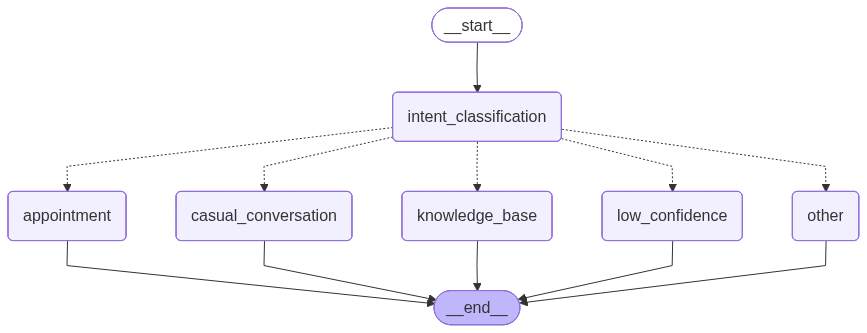

In [11]:
dependencies.workflow